# Retail Store Sales Dataset

In [ ]:
#Install Libraries
!pip -q install pandas matplotlib seaborn openpyxl

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
#Upload Dataset
from google.colab import files

uploaded = files.upload()

Saving sales_data.csv to sales_data (3).csv


In [ ]:
#Load Dataset
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Order_ID,Customer_Name,Product,Category,Region,Quantity,Sales,Profit,Marketing_Spend,Payment_Method,Order_Date
0,1,Richard Mason,Keyboard,Electronics,North,3,13203,2174.05,9929,Net Banking,2024-07-09
1,2,Raymond Snyder,Mobile,Electronics,West,10,21382,2518.88,5559,Card,2024-11-16
2,3,Michael Miller,Headphones,Electronics,West,7,39207,4262.64,5470,UPI,2024-04-11
3,4,Lisa Wright,Chair,Furniture,East,5,12151,1148.65,9023,Net Banking,2024-12-30
4,5,Stephanie Arellano,Keyboard,Electronics,West,9,31286,7819.63,1917,Cash,2024-07-16


In [ ]:
#Dataset Shape
print(df.shape)

(500, 11)


In [ ]:
#Column Names
print(df.columns)

Index(['Order_ID', 'Customer_Name', 'Product', 'Category', 'Region',
       'Quantity', 'Sales', 'Profit', 'Marketing_Spend', 'Payment_Method',
       'Order_Date'],
      dtype='object')


In [ ]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         500 non-null    int64  
 1   Customer_Name    500 non-null    object 
 2   Product          500 non-null    object 
 3   Category         500 non-null    object 
 4   Region           500 non-null    object 
 5   Quantity         500 non-null    int64  
 6   Sales            500 non-null    int64  
 7   Profit           500 non-null    float64
 8   Marketing_Spend  500 non-null    int64  
 9   Payment_Method   500 non-null    object 
 10  Order_Date       500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [ ]:
#Missing Values
print(df.isnull().sum())

Order_ID           0
Customer_Name      0
Product            0
Category           0
Region             0
Quantity           0
Sales              0
Profit             0
Marketing_Spend    0
Payment_Method     0
Order_Date         0
dtype: int64


In [ ]:
#Handle Missing Values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values Handled")

Missing Values Handled


In [ ]:
#Descriptive Statistics
df.describe()

,Order_ID,Quantity,Sales,Profit,Marketing_Spend
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,5.422000,24164.048000,3641.043340,5048.820000
std,144.481833,2.819897,14007.778274,2657.522662,2748.857434
min,1.000000,1.000000,526.000000,37.900000,156.000000
25%,125.750000,3.000000,12392.500000,1461.527500,2830.000000
50%,250.500000,5.000000,23756.000000,2973.205000,4839.000000
75%,375.250000,8.000000,36264.500000,5416.055000,7470.750000
max,500.000000,10.000000,49996.000000,11568.950000,9966.000000


In [ ]:
#Categorical Analysis
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts().head())


 Customer_Name
Customer_Name
Michael Miller         2
Katherine Poole DVM    1
Jose Houston           1
Jeffery Buchanan       1
Yesenia Newman         1
Name: count, dtype: int64

 Product
Product
Tablet     61
Monitor    60
Chair      59
Laptop     52
Printer    51
Name: count, dtype: int64

 Category
Category
Electronics        343
Furniture          106
Office Supplies     51
Name: count, dtype: int64

 Region
Region
West     140
North    123
East     123
South    114
Name: count, dtype: int64

 Payment_Method
Payment_Method
Card           128
Cash           127
UPI            124
Net Banking    121
Name: count, dtype: int64

 Order_Date
Order_Date
2024-02-17    6
2024-09-17    6
2024-09-08    5
2024-06-08    5
2024-04-06    5
Name: count, dtype: int64


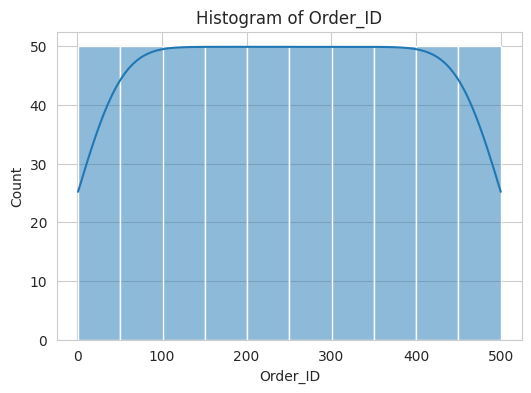

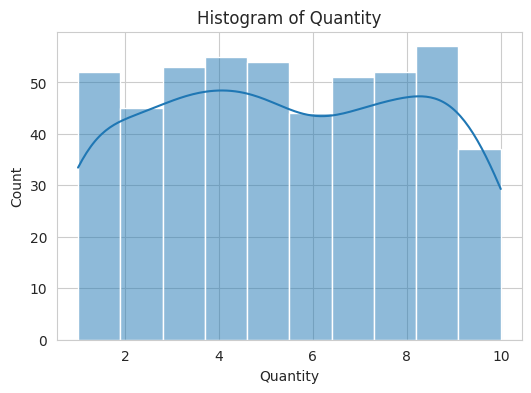

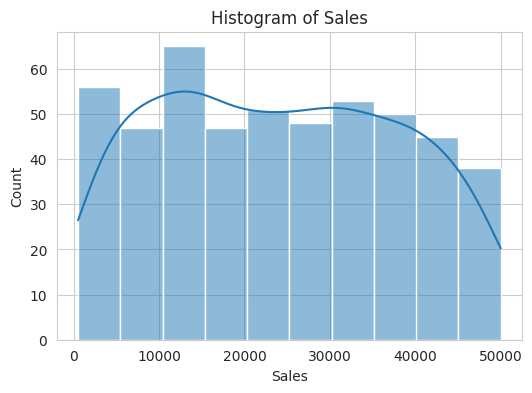

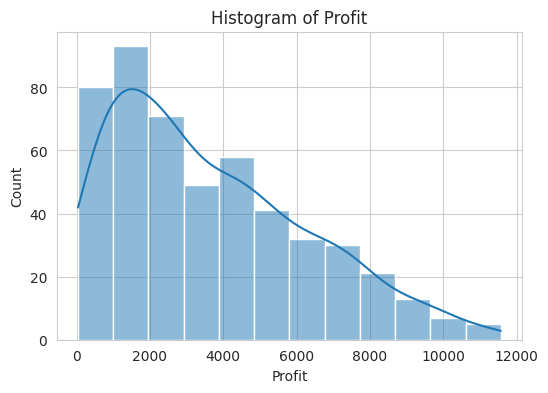

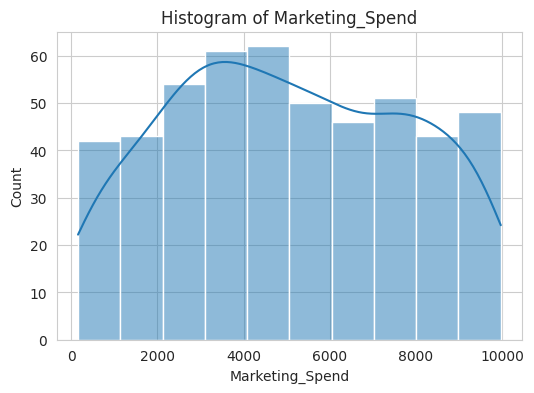

In [ ]:
#Histogram
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Histogram of {col}")

    plt.show()

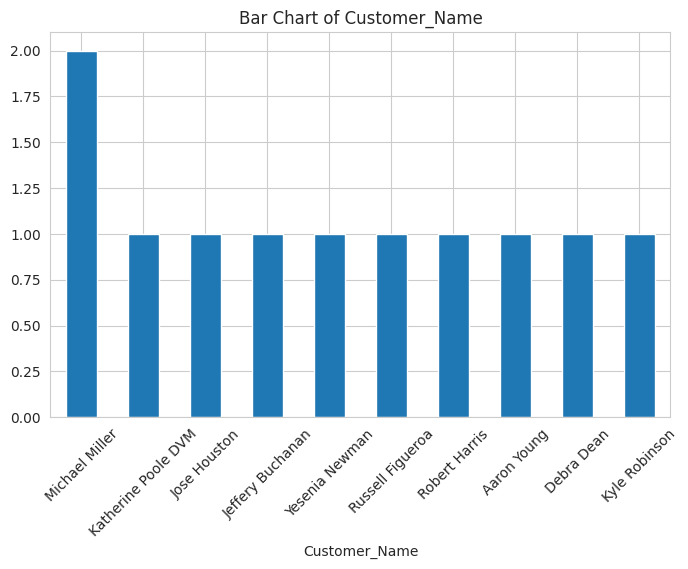

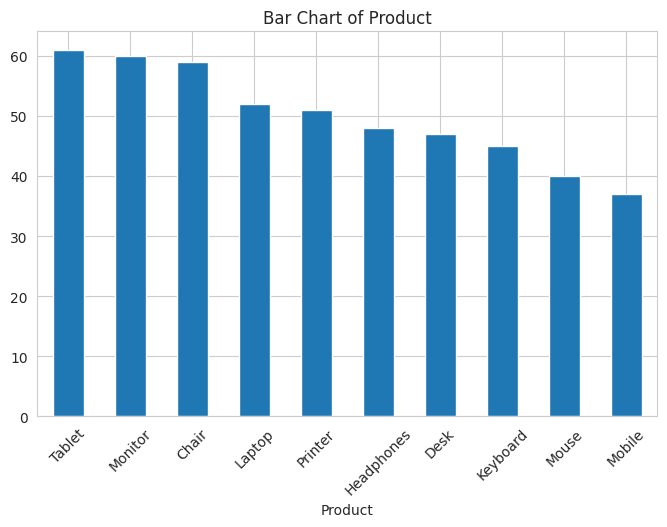

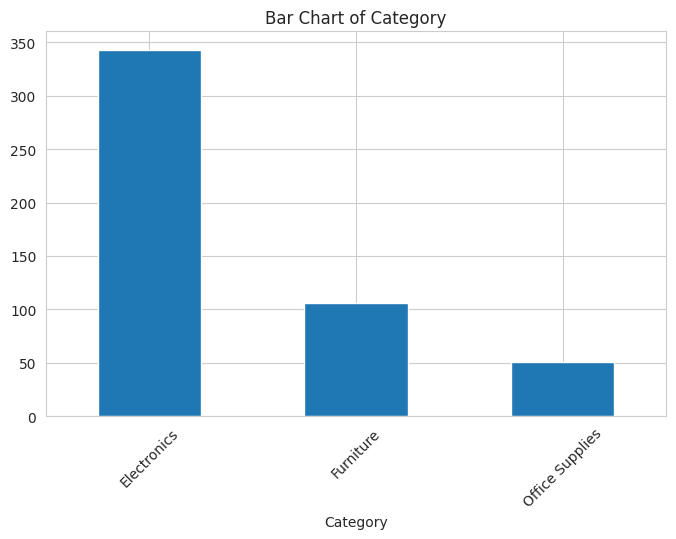

In [ ]:
#Bar Chart
for col in categorical_cols[:3]:

    plt.figure(figsize=(8,5))

    df[col].value_counts().head(10).plot(kind='bar')

    plt.title(f"Bar Chart of {col}")

    plt.xticks(rotation=45)

    plt.show()

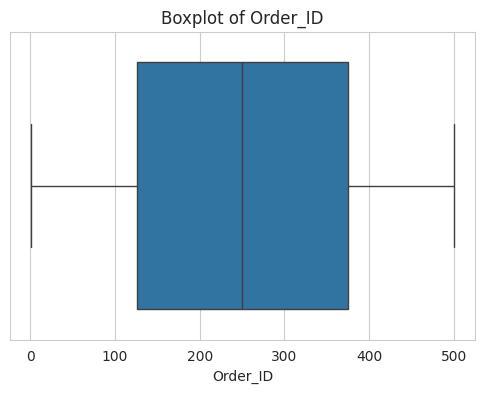

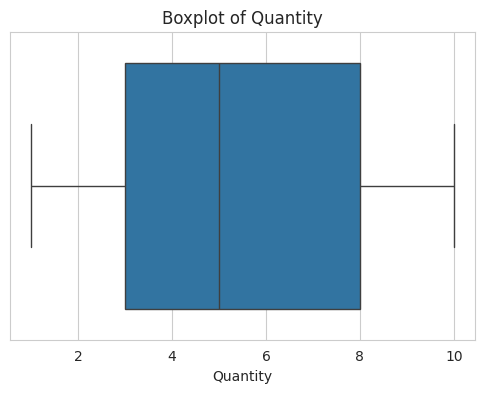

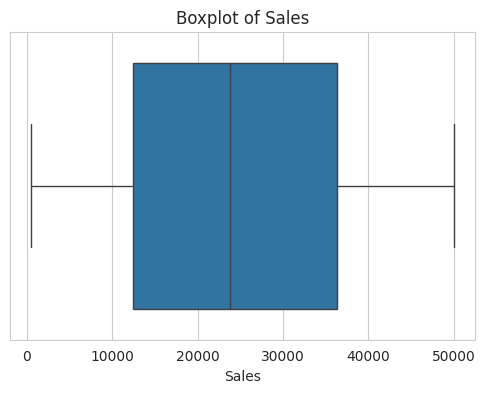

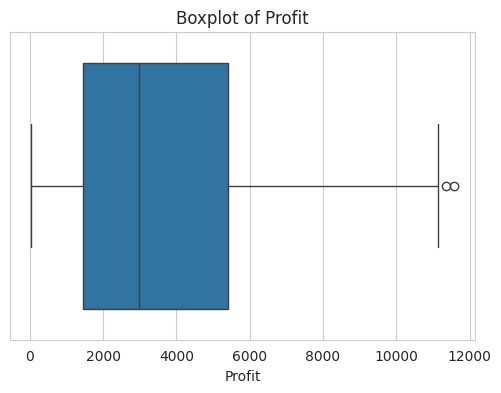

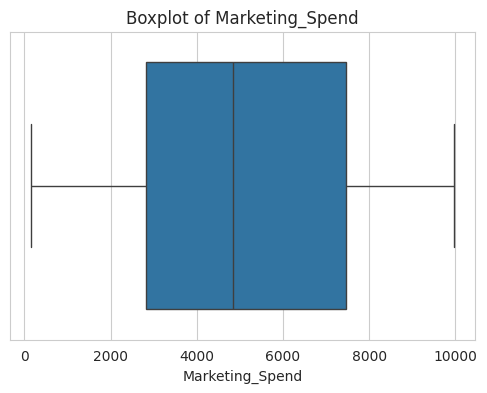

In [ ]:
#Boxplot
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

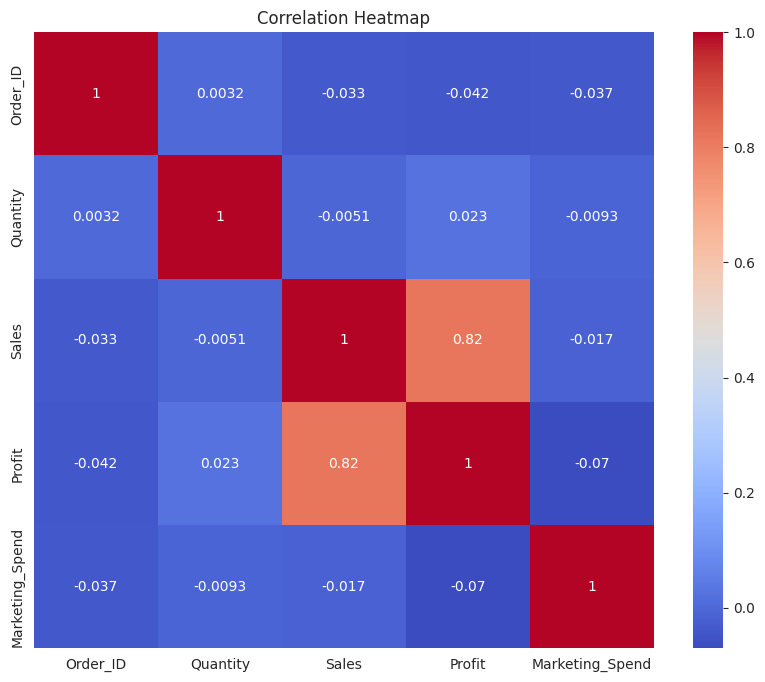

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

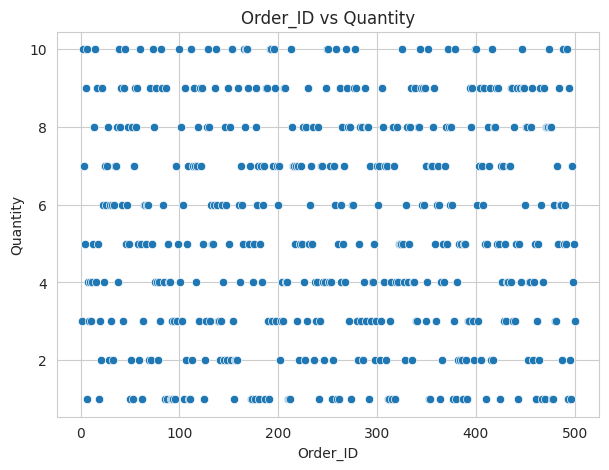

In [ ]:
#Scatter Plot
if len(numeric_cols) >= 2:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        x=df[numeric_cols[0]],
        y=df[numeric_cols[1]]
    )

    plt.title(f"{numeric_cols[0]} vs {numeric_cols[1]}")

    plt.show()

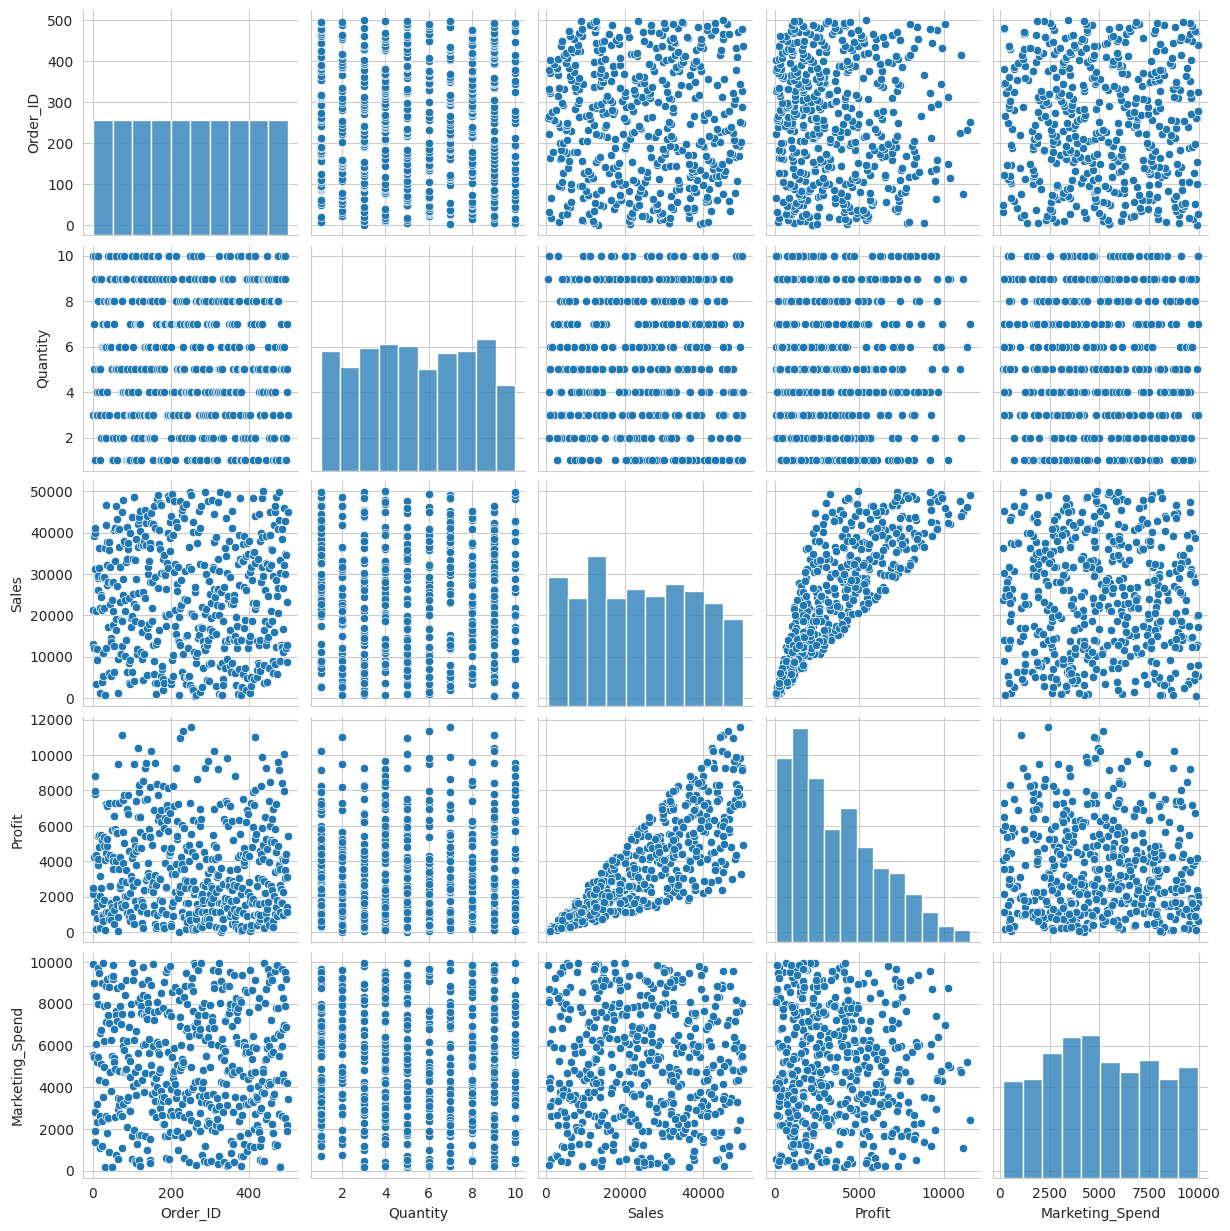

In [ ]:
#Pair Plot
sns.pairplot(df[numeric_cols])

plt.show()

In [ ]:
#Create SQL Database
conn = sqlite3.connect("business.db")

df.to_sql("sales_data", conn, if_exists="replace", index=False)

print("Database Created")

Database Created


In [ ]:
#SQL Query: Total Records
query1 = """
SELECT COUNT(*) AS Total_Records
FROM sales_data;
"""

pd.read_sql(query1, conn)

,Total_Records
0,500


In [ ]:
#SQL Query: Average Value
first_num_col = numeric_cols[0]

query2 = f"""
SELECT AVG([{first_num_col}]) AS Average_Value
FROM sales_data;
"""

pd.read_sql(query2, conn)

,Average_Value
0,250.5


In [ ]:
#SQL Query: Top Categories
first_cat_col = categorical_cols[0]

query3 = f"""
SELECT [{first_cat_col}],
COUNT(*) AS Total_Count
FROM sales_data
GROUP BY [{first_cat_col}]
ORDER BY Total_Count DESC
LIMIT 5;
"""

pd.read_sql(query3, conn)

,Customer_Name,Total_Count
0,Michael Miller,2
1,Zachary Webb,1
2,Zachary Pena,1
3,Yolanda Sanders,1
4,Yolanda Davis,1


In [ ]:
#SQL Query: Maximum Value
query4 = f"""
SELECT MAX([{first_num_col}]) AS Maximum_Value
FROM sales_data;
"""

pd.read_sql(query4, conn)

,Maximum_Value
0,500


In [ ]:
#SQL Query: Minimum Value
query5 = f"""
SELECT MIN([{first_num_col}]) AS Minimum_Value
FROM sales_data;
"""

pd.read_sql(query5, conn)

,Minimum_Value
0,1


In [ ]:
#KPI Metrics
for col in numeric_cols:

    print(f"\nColumn: {col}")

    print("SUM:", df[col].sum())

    print("AVERAGE:", df[col].mean())

    print("MAX:", df[col].max())

    print("MIN:", df[col].min())


Column: Order_ID
SUM: 125250
AVERAGE: 250.5
MAX: 500
MIN: 1

Column: Quantity
SUM: 2711
AVERAGE: 5.422
MAX: 10
MIN: 1

Column: Sales
SUM: 12082024
AVERAGE: 24164.048
MAX: 49996
MIN: 526

Column: Profit
SUM: 1820521.67
AVERAGE: 3641.0433399999997
MAX: 11568.95
MIN: 37.9

Column: Marketing_Spend
SUM: 2524410
AVERAGE: 5048.82
MAX: 9966
MIN: 156


In [ ]:
#Save & Download Dataset
df.to_csv("cleaned_dataset.csv", index=False)

print("Dataset Saved Successfully")

files.download("cleaned_dataset.csv")

Dataset Saved Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Close Database
conn.close()

print("Project Completed Successfully")

Project Completed Successfully
